In [1]:
import os
import matplotlib.pyplot as plt
import autoslo.utils.paths as pu
from autoslo.utils.colors import Palette
from autoslo.workload_execution.trace import Trace

In [2]:
pu.RunLocator._check_refresh(force=True)
df = pu.RunLocator.get_runs_df()
df

,run_id,workload_name,num_queries,scale_factor,schema_name,blueprint_name,query_router_name,maxconns,closed_loop
0,1759156767,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_16,RFixed(fixed_cluster_name='cluster_16'),1000,True
1,1759156803,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_32,RFixed(fixed_cluster_name='cluster_32'),1000,True
2,1759156811,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_64,RFixed(fixed_cluster_name='cluster_64'),1000,True
3,1759156817,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_128,RFixed(fixed_cluster_name='cluster_128'),1000,True
4,1759166300,benchmarking_workload_99_3_3_shuffled_42,891,1000,ext_tpcds1000,single_256,RFixed(fixed_cluster_name='cluster_256'),1000,True
...,...,...,...,...,...,...,...,...,...
116,1768344023,interference_light_disruptive,4765,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
117,1768351145,interference_light_disruptive_v2,4770,1000,ext_tpcds1000,single_8,RFixed(fixed_cluster_name='cluster_8'),1000,False
118,1768514009,benchmarking_workload_1_1_5,5,1000,ext_tpcds1000,single_16,RFixed(fixed_cluster_name='cluster_16'),1000,False
119,1768514142,benchmarking_workload_1_1_5,5,1000,ext_tpcds1000,single_16,RFixed(fixed_cluster_name='cluster_16'),1000,False


In [3]:
LIGHT_COMPLIANT_TEMPLATE_IDS = [42,52,55,98]
LIGHT_DISRUPTIVE_TEMPLATE_IDS = [41,8,61]
HEAVY_COMPLIANT_TEMPLATE_IDS = [47,67]
HEAVY_DISRUPTIVE_TEMPLATE_IDS = [64,72,78]
LIGHT_DISRUPTIVE_TEMPLATE_IDS_V2 = [21, 32]


In [54]:
# Plot a scatter plot where the y axis is latency, the x axis is arrival time, and the color is determined by 
# which list the template id belongs to, from the above

def plot_one(ax, workload_name, fontsize=14, legend_outside=False, show_title=True, hide_middle_shaded=False, ymin=None, ymax=None, hide_legend=False):

    run_id = pu.RunLocator.get_run_ids(workload_name=workload_name)[0]

    trace = Trace(run_id=run_id)
    latencies = trace.latencies_s
    arrival_times = trace.arrival_times()
    tpcds_temp_and_q_idx = trace.tpcds_temp_and_q_idxs

    df = latencies.to_frame(name='latency_s').merge(arrival_times.to_frame(name='arrival_time'), left_index=True, right_index=True)
    df = df.merge(tpcds_temp_and_q_idx.to_frame(name='tpcds_temp_and_q_idx'), left_index=True, right_index=True)
    min_arrival_time = df['arrival_time'].min()
    df['relative_arrival_time'] = (df['arrival_time'] - min_arrival_time).dt.total_seconds()
    df['template_id'] = df['tpcds_temp_and_q_idx'].apply(lambda x: int(x.split('_')[0]))
    df['color'] = df['template_id'].apply(
        lambda tid: Palette.light_green if tid in LIGHT_COMPLIANT_TEMPLATE_IDS else
                    Palette.light_red if tid in LIGHT_DISRUPTIVE_TEMPLATE_IDS_V2 else
                    Palette.dark_green if tid in HEAVY_COMPLIANT_TEMPLATE_IDS else
                    Palette.dark_red if tid in HEAVY_DISRUPTIVE_TEMPLATE_IDS else
                    Palette.GREY
    )
    df['label'] = df['template_id'].apply(
        lambda tid: "Light Compliant" if tid in LIGHT_COMPLIANT_TEMPLATE_IDS else
                    "Light Disruptive" if tid in LIGHT_DISRUPTIVE_TEMPLATE_IDS_V2 else
                    "Heavy Compliant" if tid in HEAVY_COMPLIANT_TEMPLATE_IDS else
                    "Heavy Disruptive" if tid in HEAVY_DISRUPTIVE_TEMPLATE_IDS else
                    "Other"
    )

    # Add some light gray backgroun over the middle ten minutes
    ax.axvspan(600, 1200, color='lightgray', alpha=0.5, zorder=0)

    if ymin is None:
        ymin = df['latency_s'].min() * 0.9
    if ymax is None:
        ymax = df['latency_s'].max() * 2
    ax.set_ylim(ymin, ymax)

    # Create a legend with the colors-to-labels mapping
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=Palette.light_green, markersize=10, label='Light Compliant'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=Palette.light_red, markersize=10, label='Light Disruptive'),    
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=Palette.dark_green, markersize=10, label='Heavy Compliant'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=Palette.dark_red, markersize=10, label='Heavy Disruptive'), 
    ]

    # Only keep the handles that actualy have points in the plot.
    unique_labels = df['label'].unique()
    handles = [h for h in handles if h.get_label() in unique_labels]

    if hide_middle_shaded:
        df = df[~((df['relative_arrival_time'] >= 600) & (df['relative_arrival_time'] <= 1200))]
        df = df[df['label'] =='Light Compliant']


    ax.scatter(df['relative_arrival_time'], df['latency_s'], color=df['color'], label=df['label'], zorder=1)
    ax.set_xlabel("Arrival Time (s)", fontsize=fontsize)
    ax.set_ylabel("Latency (s)", fontsize=fontsize)
    if show_title:
        ax.set_title(f"Interference from {workload_name.replace('_', ' ').title()} Queries", fontsize=fontsize)
    

    


    # Have vertical gridlines be every two minutes
    ax.xaxis.set_major_locator(plt.MultipleLocator(120))

    # Set x and y tick font size
    ax.tick_params(axis='x', labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)

    

    # Flot a dashed line with the p95 latency of the light green queries over
    # each two minute interval
    time_bins = range(0, int(df['relative_arrival_time'].max()) + 120, 120)
    p95_latencies = []
    for i in range(len(time_bins) - 1):
        bin_df = df[(df['relative_arrival_time'] >= time_bins[i]) & (df['relative_arrival_time'] < time_bins[i+1]) & (df['label'] == 'Light Compliant')]
        if not bin_df.empty:
            p95 = bin_df['latency_s'].quantile(0.95)
            p95_latencies.append((time_bins[i] + 60, p95))  # Middle of the bin
    if p95_latencies:
        p95_color = Palette.dark_blue
        x_vals, y_vals = zip(*p95_latencies)
        if hide_middle_shaded:
            # Remove points that are in the shaded area
            x_vals = [x for x in x_vals if x < 600 or x > 1200]
            y_vals = [y for x, y in p95_latencies if x < 600 or x > 1200]

            # Plot piecewise lines
            if x_vals and y_vals:
                split_index = next((i for i, x in enumerate(x_vals) if x > 1200), len(x_vals))
                if split_index > 0:
                    ax.plot(x_vals[:split_index], y_vals[:split_index], color=p95_color, linestyle='--', label='Light Compliant P95 Latency', marker='o', zorder=2)
                if split_index < len(x_vals):
                    ax.plot(x_vals[split_index:], y_vals[split_index:], color=p95_color, linestyle='--', marker='o', zorder=2)
        else:
            ax.plot(x_vals, y_vals, color=p95_color, linestyle='--', label='Light Compliant P95 Latency', marker='o', zorder=2)

        # Add a handle for the p95 line for the legend
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=p95_color, linestyle='--', markersize=10, label='Light Compliant P95 Latency'))

    if not hide_legend:
        if legend_outside:
            ax.legend(handles=handles, fontsize=fontsize, bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=2)
        else:
            ax.legend(handles=handles, fontsize=fontsize)
    ax.set_yscale('log')
    ax.grid(True)

    return ymin, ymax

KeyboardInterrupt: 

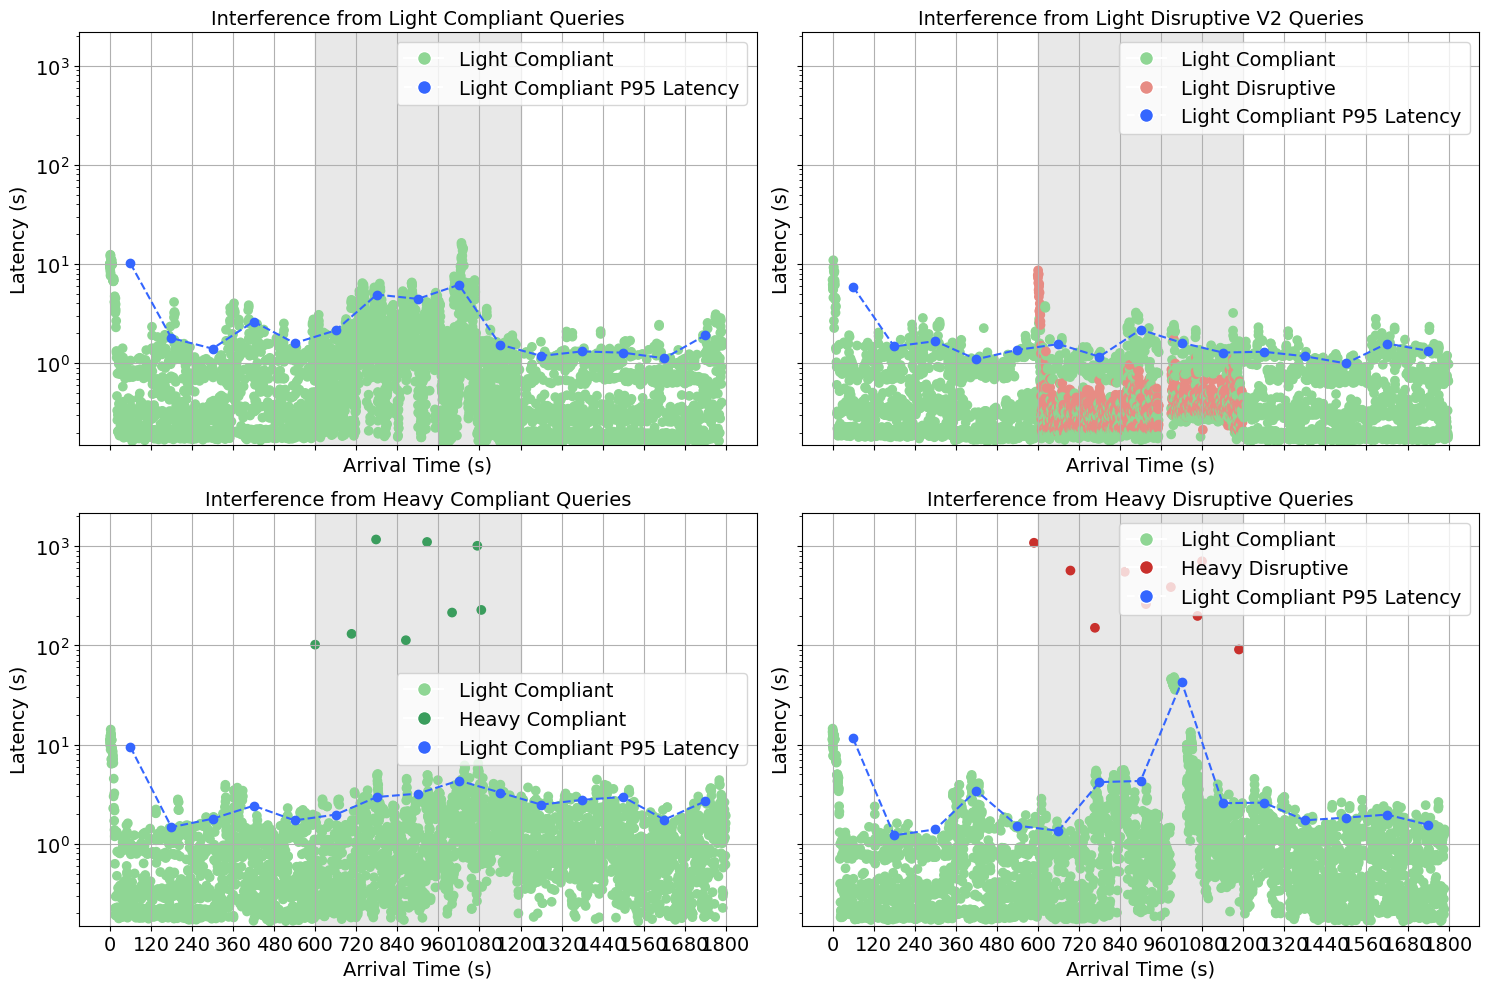

In [40]:
# Plot a 2x2 grid of the four workloads
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True)
workload_names = ['light_compliant', 'light_disruptive_v2', 'heavy_compliant', 'heavy_disruptive']
for ax, workload_name in zip(axs.flatten(), workload_names):
    plot_one(ax, workload_name)
plt.tight_layout()
plt.savefig(os.path.join(pu.AUTOSLO_ROOT, 'experiments', '11_tables_per_query', 'disruption_benchmarking_large.svg'), bbox_inches='tight')
plt.show()

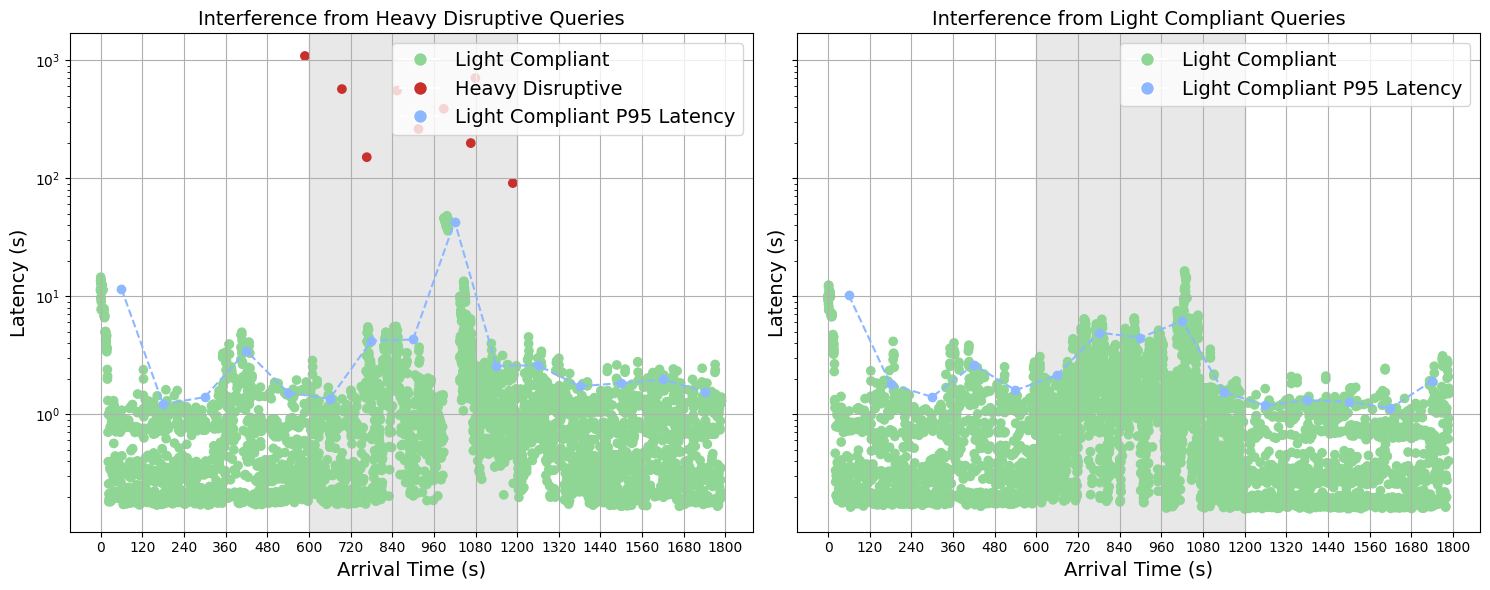

In [ ]:
# Plot a 2x2 grid of the four workloads
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
workload_names = ['heavy_disruptive', 'light_compliant']
for ax, workload_name in zip(axs.flatten(), workload_names):
    plot_one(ax, workload_name)
plt.tight_layout()
#plt.savefig(os.path.join(pu.AUTOSLO_ROOT, 'experiments', '11_tables_per_query', 'disruption_benchmarking_small.svg'), bbox_inches='tight')
plt.show()

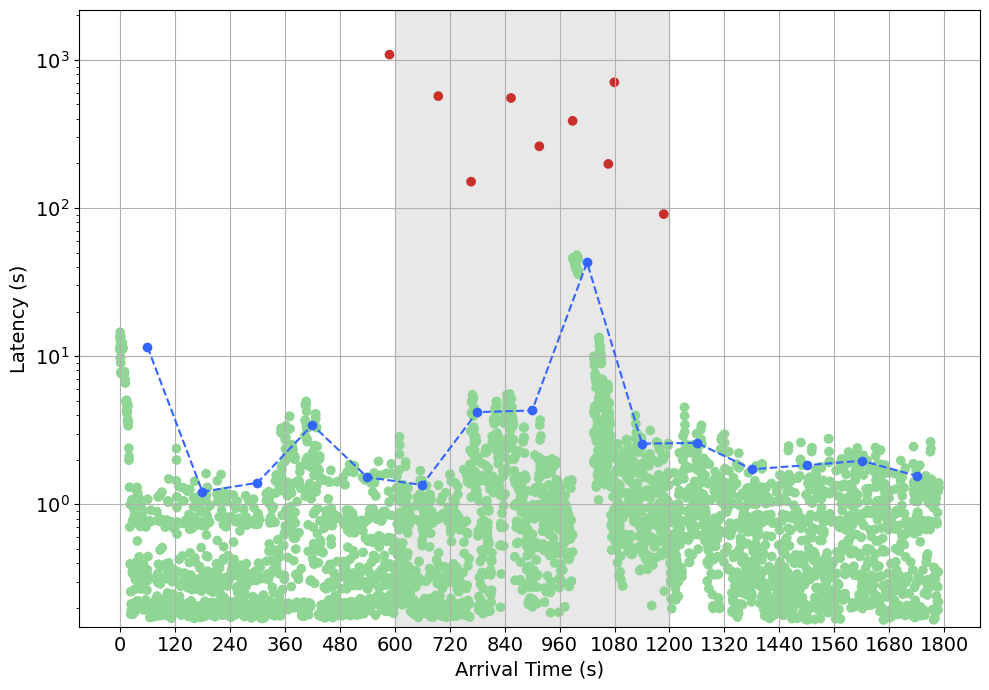

In [55]:
# Plot a 2x2 grid of the four workloads
fig, ax = plt.subplots(1, 1, figsize=(10, 7), sharex=True, sharey=True)
ymin, ymax = plot_one(ax, 'heavy_disruptive', legend_outside=True, show_title=False, hide_legend=True)
plt.tight_layout()
plt.savefig(os.path.join(pu.AUTOSLO_ROOT, 'experiments', '11_tables_per_query', 'disruption_benchmarking_heavy_disruptive.svg'), bbox_inches='tight')
plt.show()

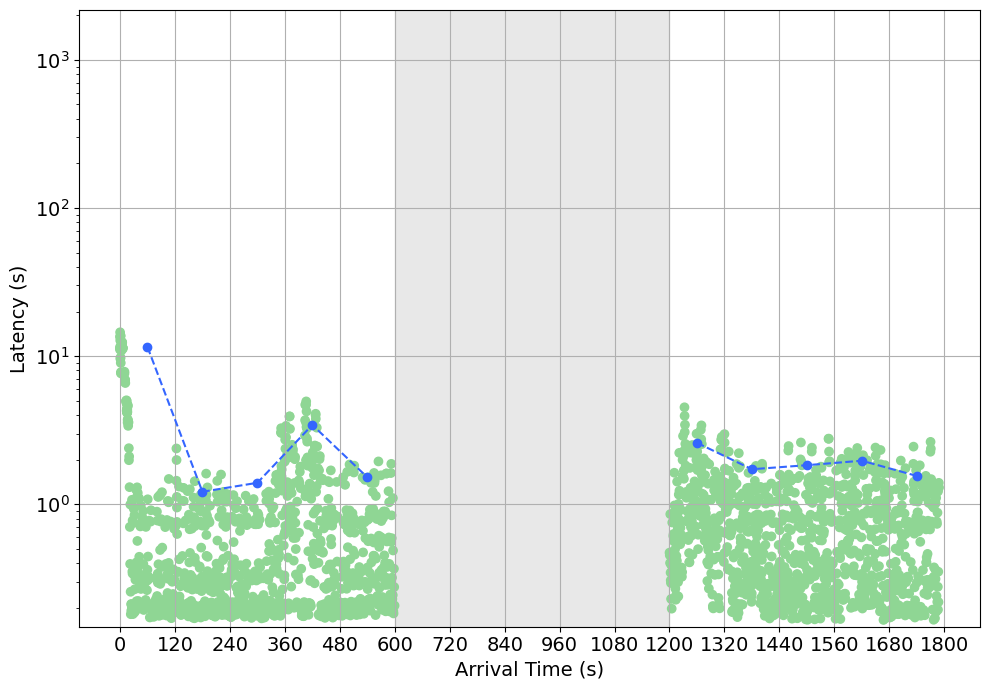

In [56]:
# Plot a 2x2 grid of the four workloads
fig, ax = plt.subplots(1, 1, figsize=(10, 7), sharex=True, sharey=True)
plot_one(ax, 'heavy_disruptive', hide_legend=True, show_title=False, hide_middle_shaded=True, ymin=ymin, ymax=ymax)
plt.tight_layout()
plt.savefig(os.path.join(pu.AUTOSLO_ROOT, 'experiments', '11_tables_per_query', 'disruption_benchmarking_heavy_disruptive_shy.svg'), bbox_inches='tight')
plt.show()

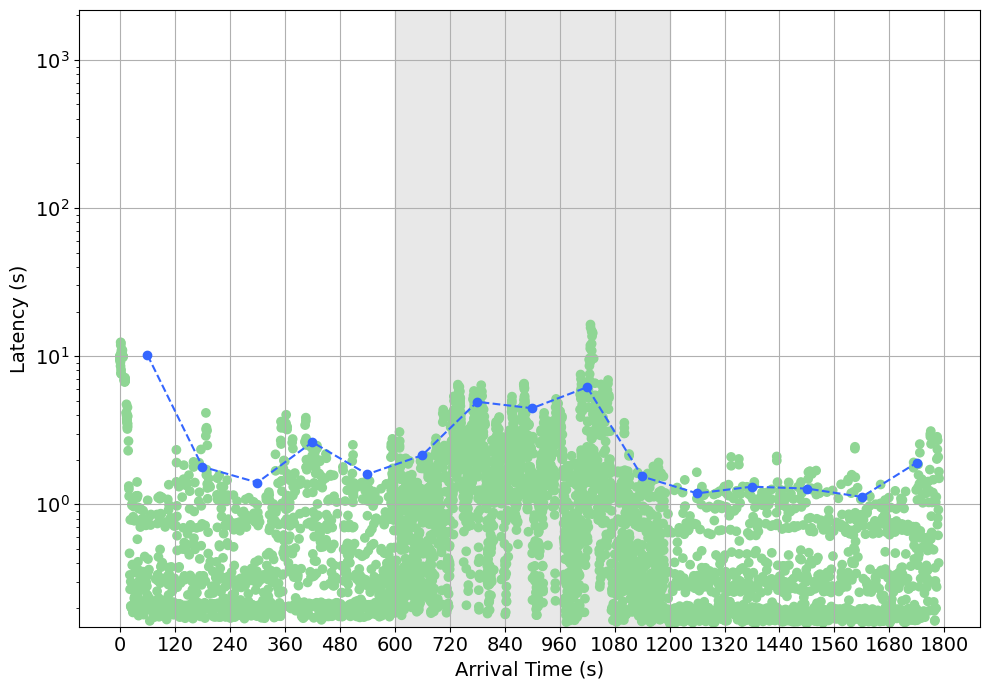

In [57]:
# Plot a 2x2 grid of the four workloads
fig, ax = plt.subplots(1, 1, figsize=(10, 7), sharex=True, sharey=True)
plot_one(ax, 'light_compliant', hide_legend=True, show_title=False, ymin=ymin, ymax=ymax)
plt.tight_layout()
plt.savefig(os.path.join(pu.AUTOSLO_ROOT, 'experiments', '11_tables_per_query', 'disruption_benchmarking_light_compliant.svg'), bbox_inches='tight')
plt.show()

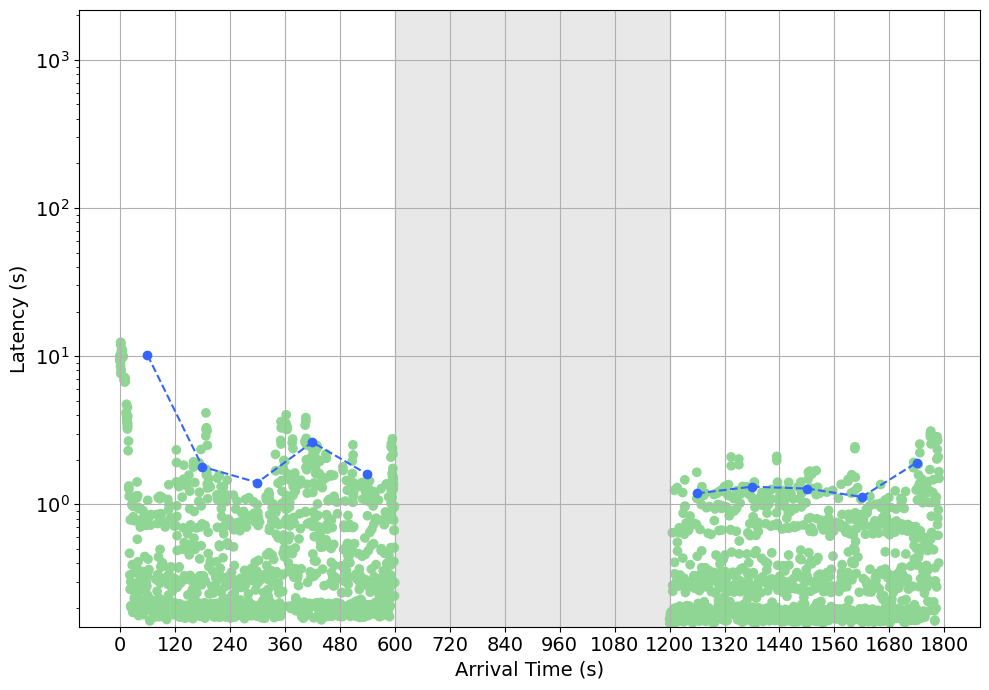

In [58]:
# Plot a 2x2 grid of the four workloads
fig, ax = plt.subplots(1, 1, figsize=(10, 7), sharex=True, sharey=True)
plot_one(ax, 'light_compliant', hide_legend=True, show_title=False, hide_middle_shaded=True, ymin=ymin, ymax=ymax)
plt.tight_layout()
plt.savefig(os.path.join(pu.AUTOSLO_ROOT, 'experiments', '11_tables_per_query', 'disruption_benchmarking_light_compliant_shy.svg'), bbox_inches='tight')
plt.show()